## Batch Normalization

**Batch Normalization (BatchNorm)** is a technique that makes neural network training **faster and more stable**.

### How it works

For each mini-batch:

1. Calculate the **mean** and **variance**.
2. **Normalize** the activations.
3. Apply learnable **scale (γ)** and **shift (β)**.

### Benefits

- **Faster training**
- **More stable training**
- Allows **higher learning rates**
- Less sensitive to **weight initialization**
- Provides a small **regularization effect**

### Where is it used?

Usually:

`Linear/Conv → BatchNorm → Activation`

### Simple Intuition

> Batch Normalization keeps the values flowing through the network in a reasonable range, helping the model learn **faster and more smoothly**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

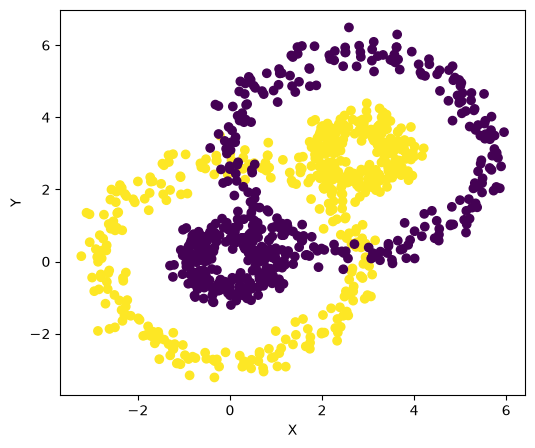

In [3]:
# 1. First concentric circle (centered at [0, 0])
#    Inner circle = Class 0 (Purple), Outer circle = Class 1 (Yellow)
X1, y1 = make_circles(n_samples=500, factor=0.3, noise=0.08, random_state=42)
X1 = X1 * 2.8               # Scale radius
y1 = 1 - y1                 # Invert labels (0 = inner, 1 = outer)
# 2. Second concentric circle (shifted to [3, 3])
#    Inner circle = Class 1 (Yellow), Outer circle = Class 0 (Purple)
X2, y2 = make_circles(n_samples=500, factor=0.3, noise=0.08, random_state=42)
X2 = (X2 * 2.8) + [2.8, 3.0] # Scale and shift center
# y2 stays as is (1 = inner, 0 = outer)
# 3. Combine both datasets
X = np.vstack([X1, X2])
y = np.hstack([y1, y2])
# 4. Create the DataFrame
df = pd.DataFrame({
    'X': X[:, 0],
    'Y': X[:, 1],
    'class': y
})
# 5. Plot
plt.figure(figsize=(6, 5))
plt.scatter(df['X'], df['Y'], c=df['class'])
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [4]:
df.head()

,X,Y,class
0,-0.788130,0.458830,0
1,-0.297243,2.795777,1
2,-0.712555,0.054302,0
3,-1.778487,-1.797698,1
4,-2.251186,1.815351,1


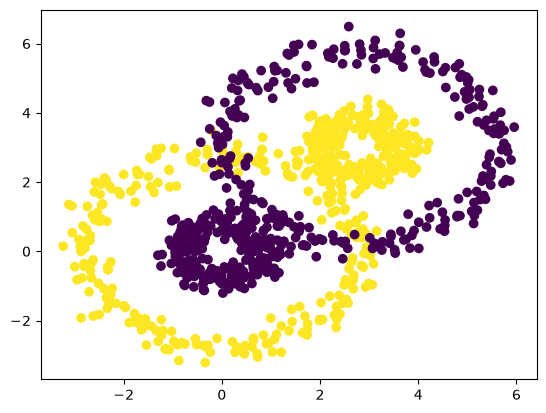

In [5]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [6]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

In [8]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

c:\Users\sujat\projects\DeepLearning\100-Days-of-Deep-Learning\myvenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5100 - loss: 1.2955 - val_accuracy: 0.5000 - val_loss: 1.6858
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5125 - loss: 1.2013 - val_accuracy: 0.5000 - val_loss: 1.5279
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5175 - loss: 1.1200 - val_accuracy: 0.5000 - val_loss: 1.3869
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5250 - loss: 1.0487 - val_accuracy: 0.5000 - val_loss: 1.2722
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5425 - loss: 0.9911 - val_accuracy: 0.5000 - val_loss: 1.1708
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5675 - loss: 0.9419 - val_accuracy: 0.5000 - val_loss: 1.0902
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5825 - loss: 0.9002 - val_accuracy: 0.5000 - val_loss: 1.0276
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5888 - loss: 0.8678 - val_accuracy: 0.5050 

In [11]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [13]:
history2 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5713 - loss: 0.9659 - val_accuracy: 0.6300 - val_loss: 0.6734
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5975 - loss: 0.9010 - val_accuracy: 0.6400 - val_loss: 0.6607
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5888 - loss: 0.8764 - val_accuracy: 0.6400 - val_loss: 0.6541
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6200 - loss: 0.8190 - val_accuracy: 0.6350 - val_loss: 0.6522
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6087 - loss: 0.7882 - val_accuracy: 0.6250 - val_loss: 0.6540
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6263 - loss: 0.7511 - val_accuracy: 0.6400 - val_loss: 0.6584
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6388 - loss: 0.7292 - val_accuracy: 0.6400 - val_loss: 0.6632
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6388 - loss: 0.7167 - val_accuracy: 0.

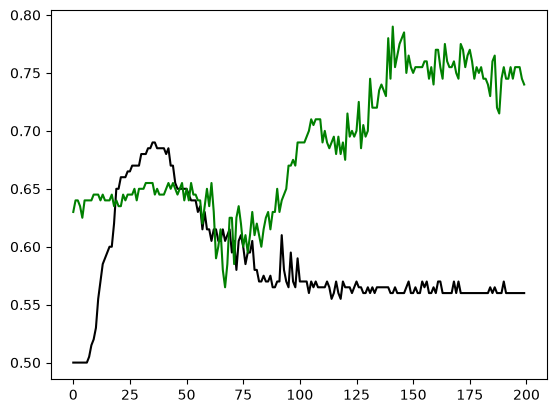

In [14]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')

### Interpretation of Validation Accuracy Graph

- **Black Line (Without Batch Normalization - history1):**
  - The model quickly increases in validation accuracy up to ~68% around epoch 35, but then suffers performance degradation and collapses down to ~56%, plateauing for the remaining ~150 epochs.
  - *Reason:* Without Batch Normalization, internal covariate shift and unstable gradient propagation cause the network to get trapped in a suboptimal local minimum/saddle point.

- **Green Line (With Batch Normalization - history2):**
  - The model shows steady learning progression, breaks out after epoch ~90, and reaches **~75% - 79% validation accuracy** (peaking around epochs 140–160) and sustains high performance.
  - *Reason:* Batch Normalization standardizes layer activations across mini-batches, smoothing the loss landscape, stabilizing training, and enabling the optimizer to learn complex non-linear decision boundaries.

**Conclusion:** Batch Normalization prevents the network from getting stuck, accelerates convergence, and delivers a **~20% boost in validation accuracy** on non-linear datasets.